# To Plot Histogram of N_r for Each Link Under No Interference

## Imports

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob, os
from tqdm import tqdm
from multiprocessing.pool import Pool

def load_num_reliable(scenario_path):
    # Get USI
    scenario_params = scenario_path.split("/")[-1].split("_")
    usi = [param for param in scenario_params if "UAVSendingInterval" in param][0].split("-")[-1]
    # Load DL Throughput
    dl_df_list = []
    dl_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Downlink_Throughput.csv"))
    for file in dl_num_reliable_files:
        measured_df = pd.read_csv(file)
        dl_df_list.append(measured_df)
    if len(dl_df_list) > 0:
        dl_df = pd.concat(dl_df_list)
    else:
        dl_df = pd.DataFrame({})
        print(scenario_path)
    # Load UL Throughput
    ul_df_list = []
    ul_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Uplink_Throughput.csv"))
    for file in ul_num_reliable_files:
        measured_df = pd.read_csv(file)
        ul_df_list.append(measured_df)
    if len(ul_df_list) > 0:
        ul_df = pd.concat(ul_df_list)
    else:
        ul_df = pd.DataFrame({})
        print(scenario_path)
    ul_df["USI"] = usi
    # Load Video Throughput
    vid_df_list = []
    vid_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Video_Throughput.csv"))
    for file in vid_num_reliable_files:
        measured_df = pd.read_csv(file)
        vid_df_list.append(measured_df)
    if len(vid_df_list) > 0:
        vid_df = pd.concat(vid_df_list)
    else:
        vid_df = pd.DataFrame({})
        print(scenario_path)

    return (dl_df, ul_df, vid_df)

## Compile Data

In [1]:
NUM_PROCS = 32
REL_TH = 0.999
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_no_int_test_processed" 
scenario_paths = glob.glob(DATASET_PATH + "/*")

dl_num_reliable_df_list = []
ul_num_reliable_df_list = []
vid_num_reliable_df_list = []
with Pool(NUM_PROCS) as pool:
    # for result in pool.starmap(load_num_reliable, zip(scenario_paths, max_num_reliable_dl, max_num_reliable_ul, max_num_reliable_vid)):
    for result in pool.starmap(load_num_reliable, zip(scenario_paths)):
        dl_num_reliable_df_list.append(result[0])
        ul_num_reliable_df_list.append(result[1])
        vid_num_reliable_df_list.append(result[2])

dl_num_reliable_df = pd.concat(dl_num_reliable_df_list)
ul_num_reliable_df = pd.concat(ul_num_reliable_df_list)
vid_num_reliable_df = pd.concat(vid_num_reliable_df_list)

# There could be some datapoints with 0 throughput and nan measured reliability
dl_num_reliable_df.dropna(subset=["Measured_Reliability", "Num_Reliable"], inplace=True)
ul_num_reliable_df.dropna(subset=["Measured_Reliability", "Num_Reliable"], inplace=True)
vid_num_reliable_df.dropna(subset=["Measured_Reliability", "Num_Reliable"], inplace=True)

# Filter samples with "Time" < 1
dl_num_reliable_df = dl_num_reliable_df.loc[dl_num_reliable_df["Time"] >= 1]
ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
vid_num_reliable_df = vid_num_reliable_df.loc[vid_num_reliable_df["Time"] >= 1]

# Filter samples with "Measured_Reliability" < 0.999
dl_num_reliable_df = dl_num_reliable_df.loc[dl_num_reliable_df["Measured_Reliability"] >= REL_TH]
ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Measured_Reliability"] >= REL_TH]
vid_num_reliable_df = vid_num_reliable_df.loc[vid_num_reliable_df["Measured_Reliability"] >= REL_TH]

## Plot Histogram

(168.0, 178.0)

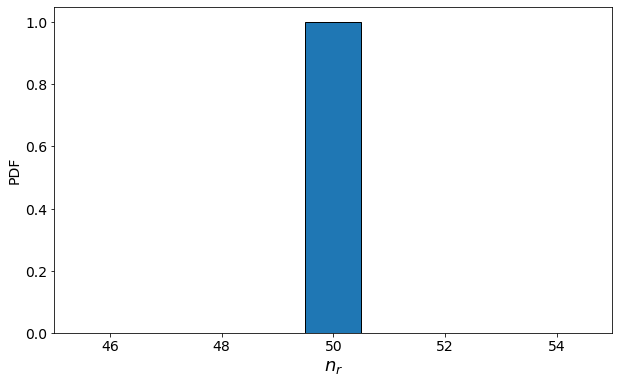

<Figure size 432x288 with 0 Axes>

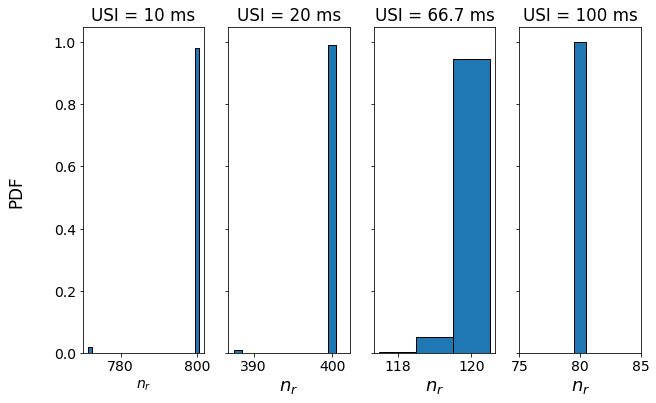

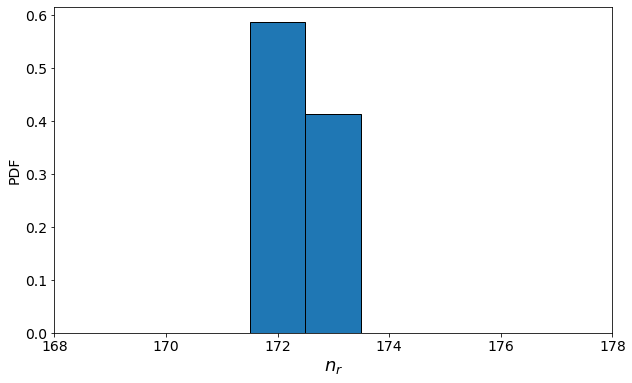

In [52]:
def hist_bin(arr):
    # arr is the unique values df["Num_Reliable"].unique()
    bin = []
    for n in arr:
        bin.append(n-0.5)
        bin.append(n+0.5)
    return np.array(bin)

# For DL
bins = np.sort(np.unique(hist_bin(np.sort(dl_num_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(dl_num_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.hist(bins[:-1], bins, weights=values, edgecolor='k')
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.xlim(45, 55)

# For UL
plt.figure()
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, sharey=True, figsize=(10,6))
ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == "10"]
bins = np.sort(np.unique(hist_bin(np.sort(ul_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_df["Num_Reliable"], bins=bins, density=True)
ax1.hist(bins[:-1], bins, weights=values, edgecolor='k')
ax1.set_xlabel("$n_{r}$")
ax1.set_title("USI = 10 ms")
ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == "20"]
bins = np.sort(np.unique(hist_bin(np.sort(ul_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_df["Num_Reliable"], bins=bins, density=True)
ax2.hist(bins[:-1], bins, weights=values, edgecolor='k')
ax2.set_xlabel("$n_{r}$", fontsize=18)
ax2.set_title("USI = 20 ms")
ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == "66.7"]
bins = np.sort(np.unique(hist_bin(np.sort(ul_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_df["Num_Reliable"], bins=bins, density=True)
ax3.hist(bins[:-1], bins, weights=values, edgecolor='k')
ax3.set_xlabel("$n_{r}$", fontsize=18)
ax3.set_title("USI = 66.7 ms")
ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == "100"]
bins = np.sort(np.unique(hist_bin(np.sort(ul_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_df["Num_Reliable"], bins=bins, density=True)
ax4.hist(bins[:-1], bins, weights=values, edgecolor='k')
ax4.set_xlabel("$n_{r}$", fontsize=18)
ax4.set_xlim(75, 85)
ax4.set_title("USI = 100 ms")
fig.supylabel("PDF")

# For Video
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
bins = np.sort(np.unique(hist_bin(np.sort(vid_num_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(vid_num_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, edgecolor='k')
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.xlim(168, 178)


# Plot Histogram of N_r For Reliable Runs Under Interference Scenarios

## Imports

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob, os
from tqdm import tqdm
from multiprocessing.pool import Pool
from itertools import repeat

def load_num_reliable(scenario_path, rel_th):
    # Get USI
    scenario_params = scenario_path.split("/")[-1].split("_")
    usi = [param for param in scenario_params if "UAVSendingInterval" in param][0].split("-")[-1]
    # Get the run no. that are reliable
    sim_results_df = pd.read_csv(os.path.join(scenario_path, "Simulation_Results.csv"))
    sim_results_df = sim_results_df.loc[(sim_results_df["Total_Reliability_DL"]>=rel_th) & (sim_results_df["Total_Reliability_UL"]>=rel_th) & (sim_results_df["Total_Reliability_VID"]>=rel_th)]
    run_num = sim_results_df["Run"].values
    # Load DL Throughput
    dl_df_list = []
    # dl_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Downlink_Throughput.csv"))
    for num in run_num:
        dl_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-{}_*_Downlink_Throughput.csv".format(num)))
        for file in dl_num_reliable_files:
            measured_df = pd.read_csv(file)
            dl_df_list.append(measured_df)
    if len(dl_df_list) > 0:
        dl_df = pd.concat(dl_df_list)
    else:
        dl_df = pd.DataFrame({})
        # print(scenario_path)
    # Load UL Throughput
    ul_df_list = []
    for num in run_num:
        measured_df = pd.read_csv(os.path.join(scenario_path, "Run-{}_Uplink_Throughput.csv".format(num)))
        ul_df_list.append(measured_df)
    if len(ul_df_list) > 0:
        ul_df = pd.concat(ul_df_list)
    else:
        ul_df = pd.DataFrame({})
        # print(scenario_path)
    ul_df["USI"] = usi
    # Load Video Throughput
    vid_df_list = []
    for num in run_num:
        measured_df = pd.read_csv(os.path.join(scenario_path, "Run-{}_Video_Throughput.csv".format(num)))
        vid_df_list.append(measured_df)
    if len(vid_df_list) > 0:
        vid_df = pd.concat(vid_df_list)
    else:
        vid_df = pd.DataFrame({})
        # print(scenario_path)

    return (dl_df, ul_df, vid_df)

## Compile Data

In [41]:
NUM_PROCS = 32
REL_TH = 0.999
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_processed" 
scenario_paths = glob.glob(DATASET_PATH + "/*")

dl_num_reliable_df_list = []
ul_num_reliable_df_list = []
vid_num_reliable_df_list = []
with Pool(NUM_PROCS) as pool:
    # for result in pool.starmap(load_num_reliable, zip(scenario_paths, max_num_reliable_dl, max_num_reliable_ul, max_num_reliable_vid)):
    for result in pool.starmap(load_num_reliable, zip(scenario_paths, repeat(REL_TH))):
        dl_num_reliable_df_list.append(result[0])
        ul_num_reliable_df_list.append(result[1])
        vid_num_reliable_df_list.append(result[2])

dl_num_reliable_df = pd.concat(dl_num_reliable_df_list)
ul_num_reliable_df = pd.concat(ul_num_reliable_df_list)
vid_num_reliable_df = pd.concat(vid_num_reliable_df_list)

# There could be some datapoints with 0 throughput and nan measured reliability
dl_num_reliable_df.dropna(subset=["Measured_Reliability", "Num_Reliable"], inplace=True)
ul_num_reliable_df.dropna(subset=["Measured_Reliability", "Num_Reliable"], inplace=True)
vid_num_reliable_df.dropna(subset=["Measured_Reliability", "Num_Reliable"], inplace=True)

# Filter samples with "Time" < 1
dl_num_reliable_df = dl_num_reliable_df.loc[dl_num_reliable_df["Time"] >= 1]
ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
vid_num_reliable_df = vid_num_reliable_df.loc[vid_num_reliable_df["Time"] >= 1]

# Filter samples with "Measured_Reliability" < 0.999
dl_num_reliable_df = dl_num_reliable_df.loc[dl_num_reliable_df["Measured_Reliability"] >= REL_TH]
ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Measured_Reliability"] >= REL_TH]
vid_num_reliable_df = vid_num_reliable_df.loc[vid_num_reliable_df["Measured_Reliability"] >= REL_TH]

## Plot Histogram

(168.0, 176.0)

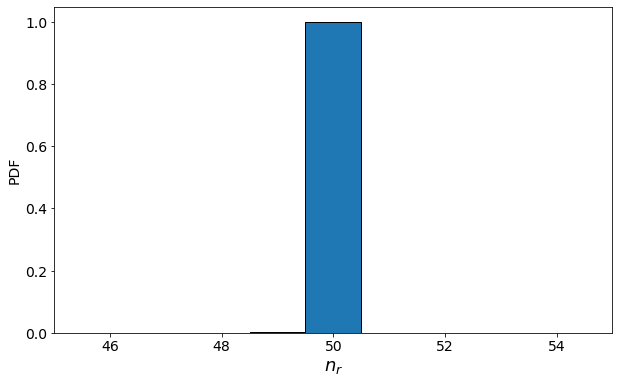

<Figure size 432x288 with 0 Axes>

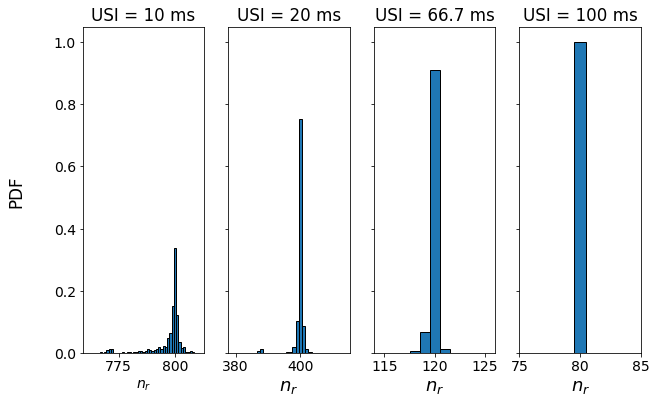

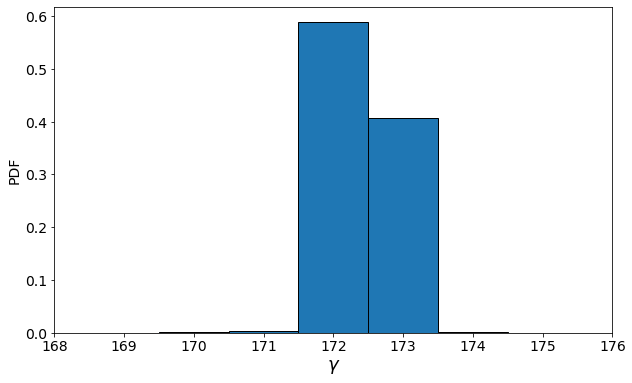

In [52]:
def hist_bin(arr):
    # arr is the unique values df["Num_Reliable"].unique()
    bin = []
    for n in arr:
        bin.append(n-0.5)
        bin.append(n+0.5)
    return np.array(bin)

# For DL
bins = np.sort(np.unique(hist_bin(np.sort(dl_num_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(dl_num_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.hist(bins[:-1], bins, weights=values, edgecolor='k')
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.xlim(45, 55)

# For UL
plt.figure()
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, sharey=True, figsize=(10,6))
ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == "10"]
bins = np.sort(np.unique(hist_bin(np.sort(ul_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_df["Num_Reliable"], bins=bins, density=True)
ax1.hist(bins[:-1], bins, weights=values, edgecolor='k')
ax1.set_xlabel("$n_{r}$")
ax1.set_title("USI = 10 ms")
ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == "20"]
bins = np.sort(np.unique(hist_bin(np.sort(ul_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_df["Num_Reliable"], bins=bins, density=True)
ax2.hist(bins[:-1], bins, weights=values, edgecolor='k')
ax2.set_xlabel("$n_{r}$", fontsize=18)
ax2.set_title("USI = 20 ms")
ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == "66.7"]
bins = np.sort(np.unique(hist_bin(np.sort(ul_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_df["Num_Reliable"], bins=bins, density=True)
ax3.hist(bins[:-1], bins, weights=values, edgecolor='k')
ax3.set_xlabel("$n_{r}$", fontsize=18)
ax3.set_title("USI = 66.7 ms")
ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == "100"]
bins = np.sort(np.unique(hist_bin(np.sort(ul_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_df["Num_Reliable"], bins=bins, density=True)
ax4.hist(bins[:-1], bins, weights=values, edgecolor='k')
ax4.set_xlabel("$n_{r}$", fontsize=18)
ax4.set_xlim(75, 85)
ax4.set_title("USI = 100 ms")
fig.supylabel("PDF")

# For Video
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
bins = np.sort(np.unique(hist_bin(np.sort(vid_num_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(vid_num_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, edgecolor='k')
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.xlim(168, 176)


# Plot Histogram of All N_r Data for Each Link Under All UAV/MANET Interference Scenarios

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob, os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix
from multiprocessing.pool import Pool

def load_num_reliable(scenario_path):
    scenario_name = scenario_path.split("/")[-1]
    params = scenario_name.split("_")
    usi = [x for x in params if "UAVSendingInterval" in x][0].split('-')[-1]
    # Load DL Throughput
    dl_df_list = []
    dl_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Downlink_Throughput.csv"))
    for file in dl_num_reliable_files:
        measured_df = pd.read_csv(file)
        dl_df_list.append(measured_df)
    dl_df = pd.concat(dl_df_list)
    # Load UL Throughput
    ul_df_list = []
    ul_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Uplink_Throughput.csv"))
    for file in ul_num_reliable_files:
        measured_df = pd.read_csv(file)
        ul_df_list.append(measured_df)
    ul_df = pd.concat(ul_df_list)
    ul_df["USI"] = usi
    # Load Video Throughput
    vid_df_list = []
    vid_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Video_Throughput.csv"))
    for file in vid_num_reliable_files:
        measured_df = pd.read_csv(file)
        vid_df_list.append(measured_df)
    vid_df = pd.concat(vid_df_list)

    return (dl_df, ul_df, vid_df)

### Compile Data

In [61]:
# Run this only ONCE, to append data from multiple scenarios
dl_df_list = []
ul_df_list = []
vid_df_list = []

In [ ]:
NUM_PROCS = 32
RELIABILITY_TH = 0.999 # Threshold to evaluate interference scenarios
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_manet_interference/manet_scenario_0_processed" 

# Create dataframe of n_r thresholds for uplink
ul_n_r = {"10": 772, "20": 388, "66.7": 118, "100": 80}
dl_n_r = 50
vid_n_r = 172

scenario_paths = [x[0] for x in os.walk(DATASET_PATH) if (os.path.isdir(x[0]) and x[0]!=DATASET_PATH)]
dl_num_reliable_df_list = []
ul_num_reliable_df_list = []
vid_num_reliable_df_list = []
with Pool(NUM_PROCS) as pool:
    # for result in pool.starmap(load_num_reliable, zip(scenario_paths, max_num_reliable_dl, max_num_reliable_ul, max_num_reliable_vid)):
    # for result in pool.starmap(load_num_reliable, zip(scenario_paths, min_num_reliable_dl, min_num_reliable_ul, min_num_reliable_vid)):
    for result in pool.starmap(load_num_reliable, zip(scenario_paths)):
        dl_num_reliable_df_list.append(result[0])
        ul_num_reliable_df_list.append(result[1])
        vid_num_reliable_df_list.append(result[2])

dl_num_reliable_df = pd.concat(dl_num_reliable_df_list)
ul_num_reliable_df = pd.concat(ul_num_reliable_df_list)
vid_num_reliable_df = pd.concat(vid_num_reliable_df_list)

# Remove NaNs
dl_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
ul_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
vid_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)

# Filter samples with "Time" < 1
dl_num_reliable_df = dl_num_reliable_df.loc[dl_num_reliable_df["Time"] >= 1]
ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
vid_num_reliable_df = vid_num_reliable_df.loc[vid_num_reliable_df["Time"] >= 1]


In [73]:
dl_df_list.append(dl_num_reliable_df)
ul_df_list.append(ul_num_reliable_df)
vid_df_list.append(vid_num_reliable_df)
print(len(dl_df_list), len(ul_df_list), len(vid_df_list))

3 3 3


### Calculate Accuracy of Detection in Time Windows

In [17]:
# Run this only ONCE, to append results from multiple scenarios
results = []

In [74]:
# Get the ground truths for each time window. 0 for no failure and 1 for failure
dl_num_reliable_df["Failure_Occur"] = dl_num_reliable_df["Measured_Reliability_1"] < RELIABILITY_TH
ul_num_reliable_df["Failure_Occur"] = ul_num_reliable_df["Measured_Reliability_1"] < RELIABILITY_TH
vid_num_reliable_df["Failure_Occur"] = vid_num_reliable_df["Measured_Reliability_1"] < RELIABILITY_TH

# Get prediction for DL and Vid
dl_num_reliable_df["Failure_Predict"] = dl_num_reliable_df["Num_Reliable"] < dl_n_r
vid_num_reliable_df["Failure_Predict"] = vid_num_reliable_df["Num_Reliable"] < vid_n_r
ul_temp_list = []
for usi in ["10", "20", "66.7", "100"]:
    ul_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"]==usi]
    ul_df["Failure_Predict"] = ul_df["Num_Reliable"] < ul_n_r[usi]
    ul_temp_list.append(ul_df)
ul_num_reliable_df = pd.concat(ul_temp_list)

dl_accuracy = accuracy_score(dl_num_reliable_df["Failure_Occur"].to_numpy(), dl_num_reliable_df["Failure_Predict"].to_numpy())
ul_accuracy = accuracy_score(ul_num_reliable_df["Failure_Occur"].to_numpy(), ul_num_reliable_df["Failure_Predict"].to_numpy())
vid_accuracy = accuracy_score(vid_num_reliable_df["Failure_Occur"].to_numpy(), vid_num_reliable_df["Failure_Predict"].to_numpy())

dl_tn, dl_fp, dl_fn, dl_tp = confusion_matrix(dl_num_reliable_df["Failure_Occur"].to_numpy(), dl_num_reliable_df["Failure_Predict"].to_numpy(), labels=[0,1]).ravel()
ul_tn, ul_fp, ul_fn, ul_tp = confusion_matrix(ul_num_reliable_df["Failure_Occur"].to_numpy(), ul_num_reliable_df["Failure_Predict"].to_numpy(), labels=[0,1]).ravel()
vid_tn, vid_fp, vid_fn, vid_tp = confusion_matrix(vid_num_reliable_df["Failure_Occur"].to_numpy(), vid_num_reliable_df["Failure_Predict"].to_numpy(), labels=[0,1]).ravel()

dl_sensitivity = dl_tp / (dl_tp + dl_fn)
dl_specificity = dl_tn / (dl_tn + dl_fp)
ul_sensitivity = ul_tp / (ul_tp + ul_fn)
ul_specificity = ul_tn / (ul_tn + ul_fp)
vid_sensitivity = vid_tp / (vid_tp + vid_fn)
vid_specificity = vid_tn / (vid_tn + vid_fp)

scenario_name = DATASET_PATH.split("/")[-1]
results.append({"Scenario": scenario_name, "DL_Accuracy": dl_accuracy, "DL_Sensitivity": dl_sensitivity, "DL_Specificity": dl_specificity, "DL_TN": dl_tn, "DL_FP": dl_fp, "DL_FN": dl_fn, "DL_TP": dl_tp,
                        "UL_Accuracy": ul_accuracy, "UL_Sensitivity": ul_sensitivity, "UL_Specificity": ul_specificity, "UL_TN": ul_tn, "UL_FP": ul_fp, "UL_FN": ul_fn, "UL_TP": ul_tp,
                        "VID_Accuracy": vid_accuracy, "VID_Sensitivity": vid_sensitivity, "VID_Specificity": vid_specificity, "VID_TN": vid_tn, "VID_FP": vid_fp, "VID_FN": vid_fn, "VID_TP": vid_tp})

/tmp/ipykernel_3883002/1591547396.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ul_df["Failure_Predict"] = ul_df["Num_Reliable"] < ul_n_r[usi]
/tmp/ipykernel_3883002/1591547396.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ul_df["Failure_Predict"] = ul_df["Num_Reliable"] < ul_n_r[usi]
/tmp/ipykernel_3883002/1591547396.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

In [75]:
SAVE_PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_3_scripts/num_reliable_failure_detection_time_window_results.csv"
scenario_results_df = pd.DataFrame(results)
scenario_results_df.to_csv(SAVE_PATH)

In [ ]:
results

### Plot Histogram

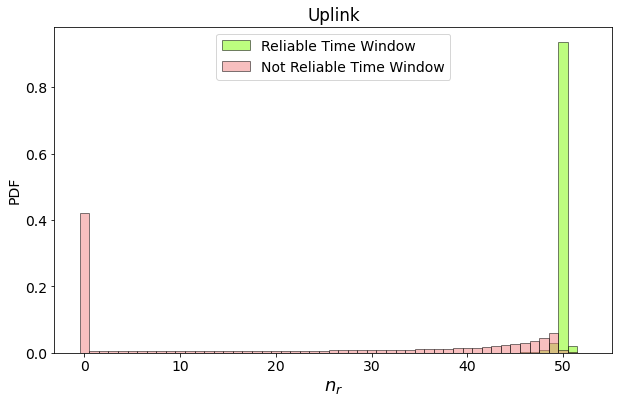

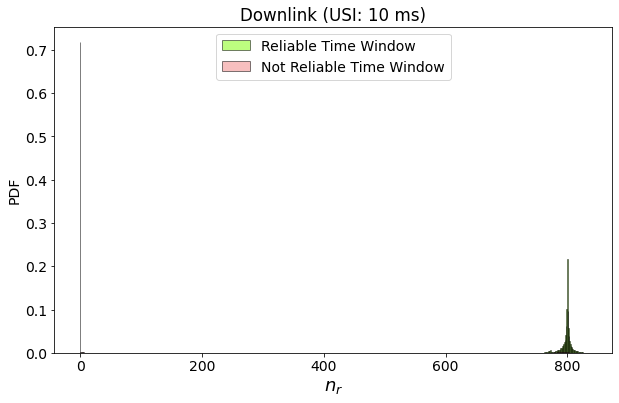

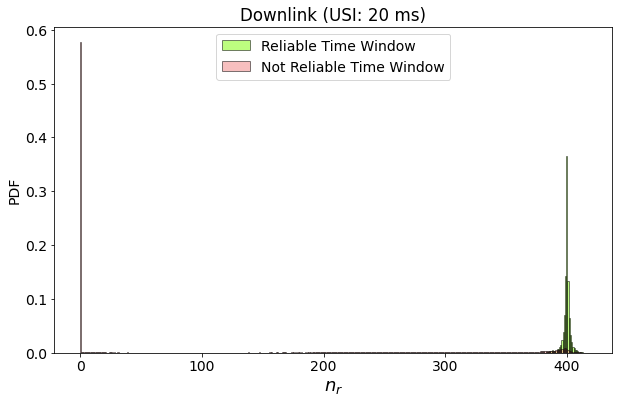

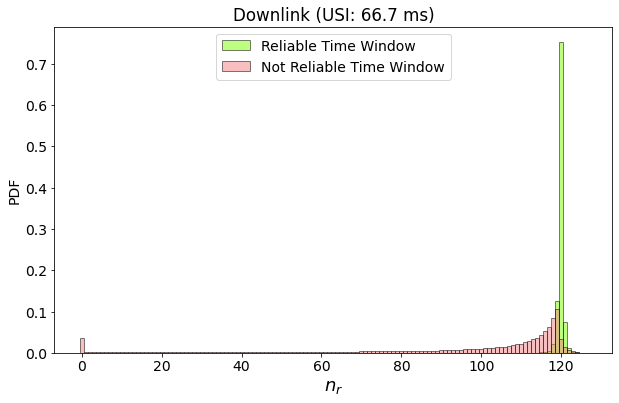

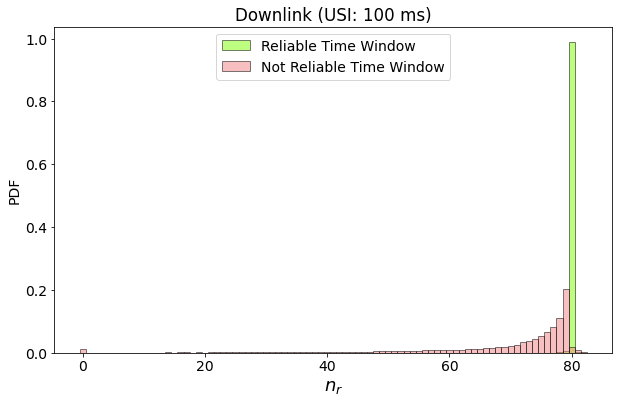

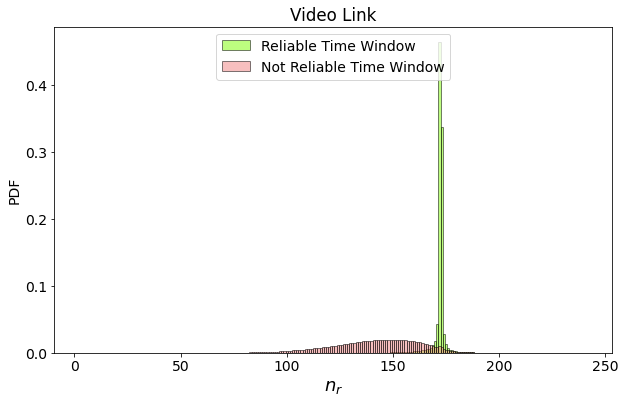

In [76]:
def hist_bin(arr):
    # arr is the unique values df["Num_Reliable"].unique()
    bin = []
    for n in arr:
        bin.append(n-0.5)
        bin.append(n+0.5)
    return np.array(bin)

# For DL
dl_df = pd.concat(dl_df_list)
dl_reliable_df = dl_df.loc[dl_df["Measured_Reliability_1"] >= RELIABILITY_TH]
dl_fail_df = dl_df.loc[dl_df["Measured_Reliability_1"] < RELIABILITY_TH]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
bins = np.sort(np.unique(hist_bin(np.sort(dl_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(dl_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(dl_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(dl_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Uplink")
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")
# plt.xlim(45, 55)

ul_df = pd.concat(ul_df_list)

# For UL USI 10 ms
temp_df = ul_df.loc[ul_df["USI"] == "10"]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= RELIABILITY_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < RELIABILITY_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Downlink (USI: 10 ms)")
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

# For UL USI 20 ms
temp_df = ul_df.loc[ul_df["USI"] == "20"]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= RELIABILITY_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < RELIABILITY_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Downlink (USI: 20 ms)")
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

# For UL USI 66.7 ms
temp_df = ul_df.loc[ul_df["USI"] == "66.7"]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= RELIABILITY_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < RELIABILITY_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Downlink (USI: 66.7 ms)")
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

# For UL USI 100 ms
temp_df = ul_df.loc[ul_df["USI"] == "100"]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= RELIABILITY_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < RELIABILITY_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Downlink (USI: 100 ms)")
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

# For Video
vid_df = pd.concat(vid_df_list)
vid_reliable_df = vid_df.loc[vid_df["Measured_Reliability_1"] >= RELIABILITY_TH]
vid_fail_df = vid_df.loc[vid_df["Measured_Reliability_1"] < RELIABILITY_TH]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
bins = np.sort(np.unique(hist_bin(np.sort(vid_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(vid_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(vid_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(vid_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Video Link")
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

### Zoom In Histogram

(125.0, 210.0)

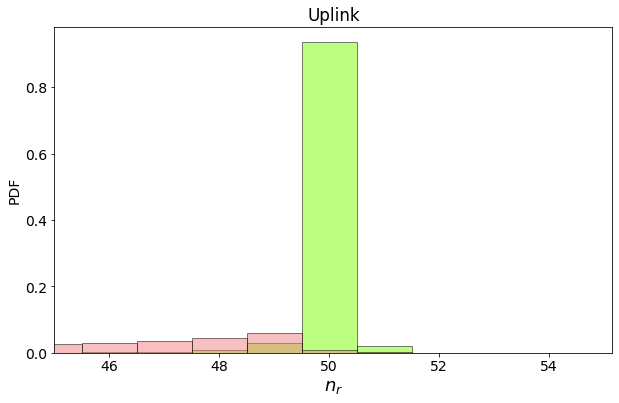

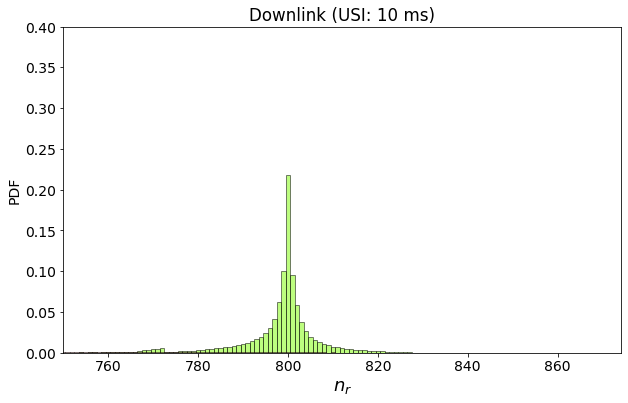

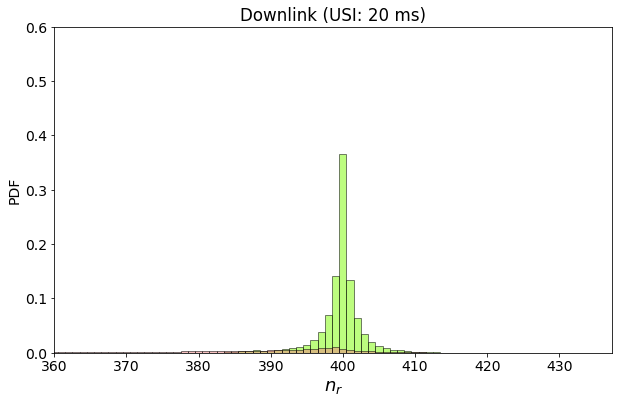

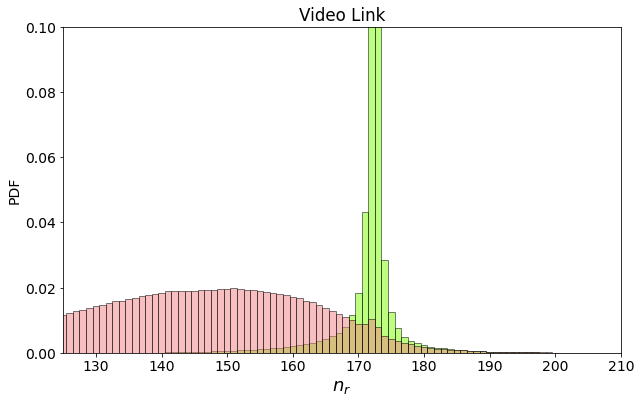

In [77]:
# For DL
dl_df = pd.concat(dl_df_list)
dl_reliable_df = dl_df.loc[dl_df["Measured_Reliability_1"] >= RELIABILITY_TH]
dl_fail_df = dl_df.loc[dl_df["Measured_Reliability_1"] < RELIABILITY_TH]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
bins = np.sort(np.unique(hist_bin(np.sort(dl_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(dl_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(dl_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(dl_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Uplink")
plt.xlim(left=45)

ul_df = pd.concat(ul_df_list)

# For UL USI 10 ms
temp_df = ul_df.loc[ul_df["USI"] == "10"]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= RELIABILITY_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < RELIABILITY_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Downlink (USI: 10 ms)")
plt.ylim(top=0.4)
plt.xlim(left=750)

# For UL USI 20 ms
temp_df = ul_df.loc[ul_df["USI"] == "20"]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= RELIABILITY_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < RELIABILITY_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Downlink (USI: 20 ms)")
plt.ylim(top=0.6)
plt.xlim(left=360)

# For Video
vid_df = pd.concat(vid_df_list)
vid_reliable_df = vid_df.loc[vid_df["Measured_Reliability_1"] >= RELIABILITY_TH]
vid_fail_df = vid_df.loc[vid_df["Measured_Reliability_1"] < RELIABILITY_TH]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
bins = np.sort(np.unique(hist_bin(np.sort(vid_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(vid_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(vid_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(vid_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$n_{r}$", fontsize=18)
plt.title("Video Link")
plt.ylim(top=0.1)
plt.xlim(left=125, right=210)

# Plot Histogram of All N_r Data for Each Link Under Specific UAV/MANET Interference Scenarios

## Imports

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob, os
from tqdm import tqdm
from multiprocessing.pool import Pool

## Load Data

In [3]:
REL_TH = 0.999
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference" 
SCENARIO = "uav_scenario_0_{}_processed.csv"
NUM_UAV = 8

dl_num_reliable_df_list = []
for i in range(NUM_UAV):
    df = pd.read_csv(os.path.join(DATASET_PATH, SCENARIO).format("UAV_" + str(i)))
    dl_num_reliable_df_list.append(df)
dl_num_reliable_df = pd.concat(dl_num_reliable_df_list)
ul_num_reliable_df = pd.read_csv(os.path.join(DATASET_PATH, SCENARIO.format("ul")))
vid_num_reliable_df = pd.read_csv(os.path.join(DATASET_PATH, SCENARIO.format("vid")))

# There could be some datapoints with 0 throughput and nan measured reliability
dl_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
ul_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
vid_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)

# Filter samples with "Time" < 1
dl_num_reliable_df = dl_num_reliable_df.loc[dl_num_reliable_df["Time"] >= 1]
ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
vid_num_reliable_df = vid_num_reliable_df.loc[vid_num_reliable_df["Time"] >= 1]

## Plot Histogram

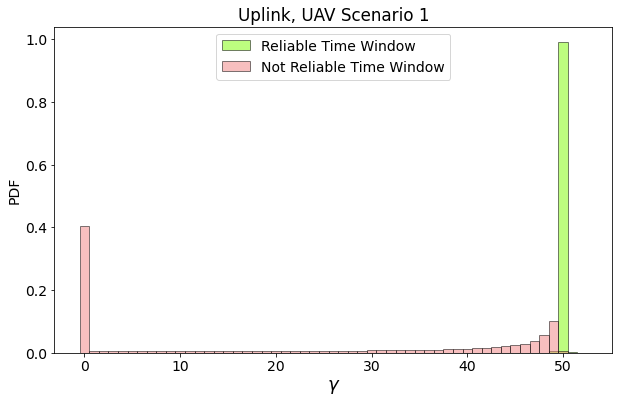

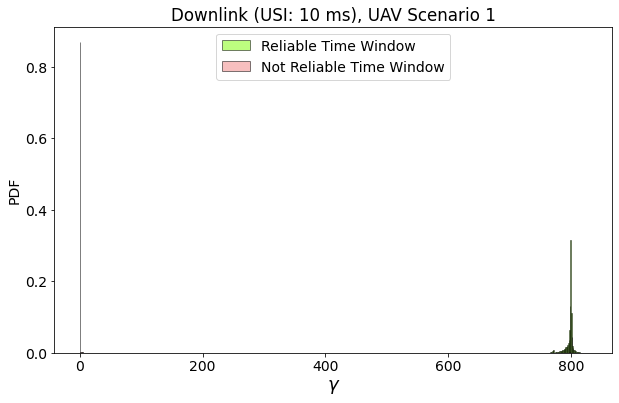

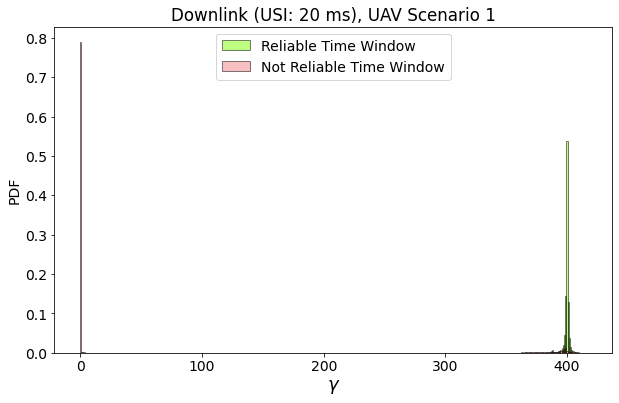

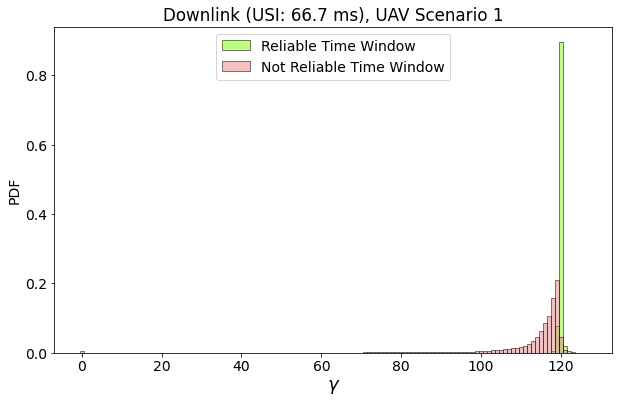

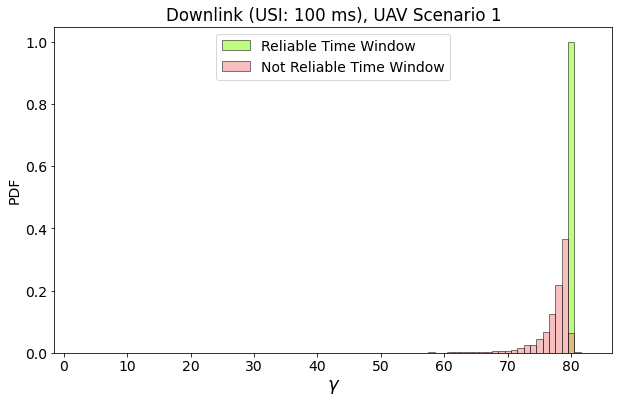

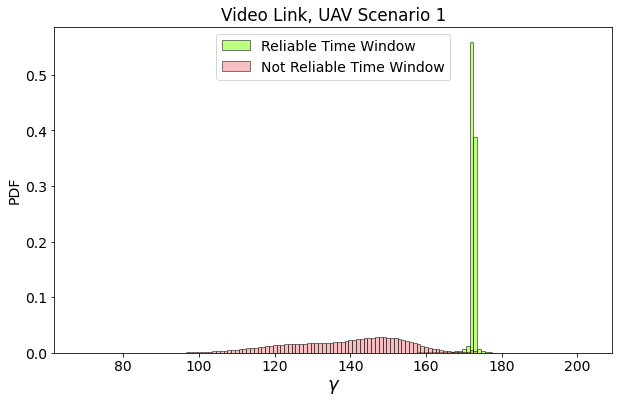

In [8]:
def hist_bin(arr):
    # arr is the unique values df["Num_Reliable"].unique()
    bin = []
    for n in arr:
        bin.append(n-0.5)
        bin.append(n+0.5)
    return np.array(bin)

scenario_legend = "UAV Scenario 1"
# For DL
dl_df = dl_num_reliable_df
dl_reliable_df = dl_df.loc[dl_df["Measured_Reliability_1"] >= REL_TH]
dl_fail_df = dl_df.loc[dl_df["Measured_Reliability_1"] < REL_TH]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
bins = np.sort(np.unique(hist_bin(np.sort(dl_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(dl_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(dl_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(dl_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$\\gamma$", fontsize=18)
plt.title("Uplink, {}".format(scenario_legend))
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")
# plt.xlim(45, 55)

ul_df = ul_num_reliable_df

# For UL USI 10 ms
temp_df = ul_df.loc[ul_df["USI"] == 10]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= REL_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < REL_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$\\gamma$", fontsize=18)
plt.title("Downlink (USI: 10 ms), {}".format(scenario_legend))
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

# For UL USI 20 ms
temp_df = ul_df.loc[ul_df["USI"] == 20]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= REL_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < REL_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$\\gamma$", fontsize=18)
plt.title("Downlink (USI: 20 ms), {}".format(scenario_legend))
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

# For UL USI 66.7 ms
temp_df = ul_df.loc[ul_df["USI"] == 66.7]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= REL_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < REL_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$\\gamma$", fontsize=18)
plt.title("Downlink (USI: 66.7 ms), {}".format(scenario_legend))
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

# For UL USI 100 ms
temp_df = ul_df.loc[ul_df["USI"] == 100]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= REL_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < REL_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$\\gamma$", fontsize=18)
plt.title("Downlink (USI: 100 ms), {}".format(scenario_legend))
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

# For Video
vid_df = vid_num_reliable_df
vid_reliable_df = vid_df.loc[vid_df["Measured_Reliability_1"] >= REL_TH]
vid_fail_df = vid_df.loc[vid_df["Measured_Reliability_1"] < REL_TH]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
bins = np.sort(np.unique(hist_bin(np.sort(vid_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(vid_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(vid_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(vid_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$\\gamma$", fontsize=18)
plt.title("Video Link, {}".format(scenario_legend))
plt.legend(["Reliable Time Window", "Not Reliable Time Window"], loc="upper center")

## Zoom In

(360.0, 420.0)

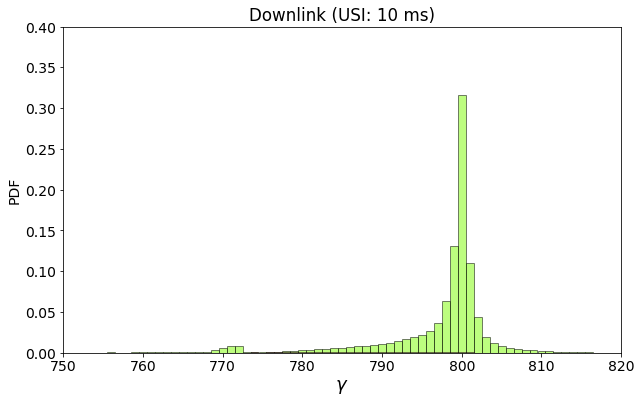

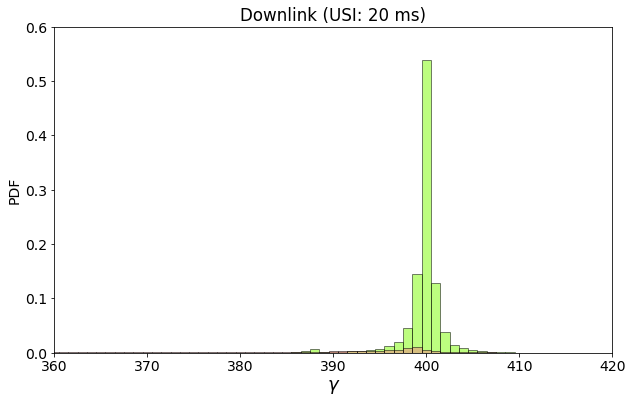

In [7]:
# # For DL
# dl_df = dl_num_reliable_df
# dl_reliable_df = dl_df.loc[dl_df["Measured_Reliability_1"] >= REL_TH]
# dl_fail_df = dl_df.loc[dl_df["Measured_Reliability_1"] < REL_TH]
# plt.figure(figsize=(10,6))
# plt.rcParams.update({'font.size': 14})
# bins = np.sort(np.unique(hist_bin(np.sort(dl_reliable_df["Num_Reliable"].unique()))))
# values, _ = np.histogram(dl_reliable_df["Num_Reliable"], bins=bins, density=True)
# plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
# bins = np.sort(np.unique(hist_bin(np.sort(dl_fail_df["Num_Reliable"].unique()))))
# values, _ = np.histogram(dl_fail_df["Num_Reliable"], bins=bins, density=True)
# plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
# plt.ylabel("PDF")
# plt.xlabel("$n_{r}$", fontsize=18)
# plt.title("Uplink")
# plt.xlim(left=40)

ul_df = ul_num_reliable_df

# For UL USI 10 ms
temp_df = ul_df.loc[ul_df["USI"] == 10]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= REL_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < REL_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$\\gamma$", fontsize=18)
plt.title("Downlink (USI: 10 ms)")
plt.ylim(top=0.4)
plt.xlim(left=750, right=820)

# For UL USI 20 ms
temp_df = ul_df.loc[ul_df["USI"] == 20]
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
ul_reliable_df = temp_df.loc[temp_df["Measured_Reliability_1"] >= REL_TH]
ul_fail_df = temp_df.loc[temp_df["Measured_Reliability_1"] < REL_TH]
bins = np.sort(np.unique(hist_bin(np.sort(ul_reliable_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_reliable_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
bins = np.sort(np.unique(hist_bin(np.sort(ul_fail_df["Num_Reliable"].unique()))))
values, _ = np.histogram(ul_fail_df["Num_Reliable"], bins=bins, density=True)
plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
plt.ylabel("PDF")
plt.xlabel("$\\gamma$", fontsize=18)
plt.title("Downlink (USI: 20 ms)")
plt.ylim(top=0.6)
plt.xlim(left=360, right=420)

# # For Video
# vid_df = vid_num_reliable_df
# vid_reliable_df = vid_df.loc[vid_df["Measured_Reliability_1"] >= REL_TH]
# vid_fail_df = vid_df.loc[vid_df["Measured_Reliability_1"] < REL_TH]
# plt.figure(figsize=(10,6))
# plt.rcParams.update({'font.size': 14})
# bins = np.sort(np.unique(hist_bin(np.sort(vid_reliable_df["Num_Reliable"].unique()))))
# values, _ = np.histogram(vid_reliable_df["Num_Reliable"], bins=bins, density=True)
# plt.hist(bins[:-1], bins, weights=values, color = "lawngreen", edgecolor='k', alpha=0.5)
# bins = np.sort(np.unique(hist_bin(np.sort(vid_fail_df["Num_Reliable"].unique()))))
# values, _ = np.histogram(vid_fail_df["Num_Reliable"], bins=bins, density=True)
# plt.hist(bins[:-1], bins, weights=values, color = "lightcoral", edgecolor='k', alpha=0.5)
# plt.ylabel("PDF")
# plt.xlabel("$n_{r}$", fontsize=18)
# plt.title("Video Link")
# plt.ylim(top=0.1)
# plt.xlim(left=125, right=210)

# Plot Reception Time, Histograms of Delay and Inter-Packet Arrival

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob, os
from tqdm import tqdm
from multiprocessing.pool import Pool

In [14]:
# First, find a run no. that is reliable given the scenario
PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_processed/UAVSpeed-24_Height-255_BitRate-13_Modulation-QPSK_UAVSendingInterval-100_Distance-420_InterferenceBitRate-26_InterferenceUSI-100"
FILE = "Simulation_Results.csv"
REL_TH = 0.999
sim_results_df = pd.read_csv(os.path.join(PATH, FILE))
sim_results_df = sim_results_df.loc[(sim_results_df["Total_Reliability_DL"]>=REL_TH) & (sim_results_df["Total_Reliability_UL"]>=REL_TH) & (sim_results_df["Total_Reliability_VID"]>=REL_TH)]
run_num = sim_results_df["Run"].values
run_num

array([ 0, 12, 14, 17, 18, 19, 20, 21, 22, 29,  2, 30, 33, 34, 35, 38, 41,
       42, 47, 48, 49, 51, 54, 55, 57, 58,  5, 60, 62, 65, 66, 68, 69, 70,
       71, 72, 76, 78, 79,  7, 81, 85, 86, 89, 90, 95, 96, 99,  9])

In [40]:
PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0/UAVSpeed-24_Height-255_BitRate-13_Modulation-QPSK_UAVSendingInterval-100_Distance-420_InterferenceBitRate-26_InterferenceUSI-100"
# PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/temp"
# FILE = "Run-0_GW-Rx.csv"
# FILE = "Run-0_GCS-Video-Rx.csv"
FILE = "Run-0_GCS-Rx.csv"

df = pd.read_csv(os.path.join(PATH, FILE))
df["Delay"] = df["RxTime"] - df["TxTime"]
inter_arr_time = df["RxTime"].diff().dropna().values


Text(0.5, 0, 'Inter-Packet Arrival Time (s)')

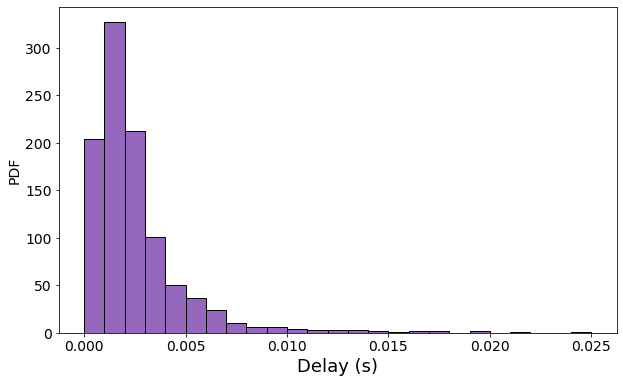

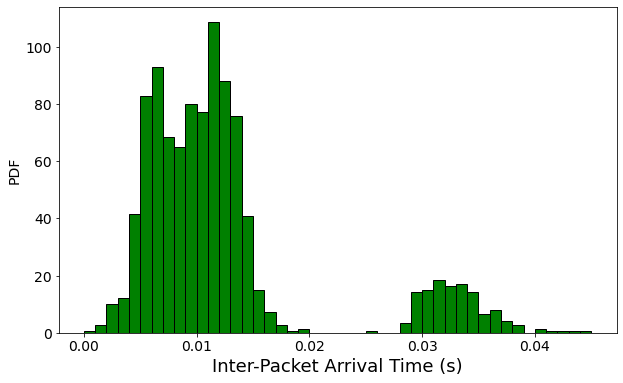

In [41]:
bins = np.linspace(0, 0.025, 26)

plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.hist(df["Delay"].values, bins=bins, density=True, facecolor='tab:purple', edgecolor="k")
plt.ylabel("PDF")
plt.xlabel("Delay (s)", fontsize=18)

bins = np.linspace(0, 0.045, 46)
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.hist(inter_arr_time, bins=bins, density=True, facecolor='g', edgecolor="k")
plt.ylabel("PDF")
plt.xlabel("Inter-Packet Arrival Time (s)", fontsize=18)